# Dataset generation v2

Two labels-only datasets built from FABSA by one pipeline with one flag. Frozen under
`benchmark_outputs/v2/`; `benchmark_builder.ipynb` reads the output.

**Easy**
- All 10 industries x 12 aspects x 3-4 orgs per industry
- Every cell has at least 30 reviews
- Sentiment proportions come from FABSA
- Every question can be answered

**Hard**
- The same 10 x 12 x 3-4 frame
- Cell sizes follow FABSA, so some industry x aspect groups are missing or very small
- Sentiment proportions come from FABSA, identical to Easy
- Some questions have no answer. The agent should report insufficient data rather than make
  unsupported claims

Sparsity is the only difference between them, which is what makes an Easy-to-Hard comparison
attributable to sparsity alone.

In [17]:
import itertools
from collections import namedtuple
from pathlib import Path

import pandas as pd, numpy as np

VERSION = "v2"
SEED    = 29
PREVIEW = "hard"        # both datasets are always built; this only picks the one shown
                        # in the preview cells and the recovery chart: "easy" | "hard"

MIN_REVIEWS = 30              # Easy floor; also the threshold a question needs to be answerable
DROP_RATE   = 0.10            # Hard only: chance an org loses an aspect its industry has (step 5)
SIZE_JITTER = (0.6, 1.4)      # cell size resamples FABSA's volume within this band (step 6)
NEG_LIMITS  = (0.02, 0.95)    # a planted negative rate is kept inside this range (step 4)
MIN_MARGIN  = 0.05            # an org's worst aspect must beat its runner-up by this (step 4)

SENTIMENTS = ["positive", "negative", "neutral"]
OUT_DIR    = Path("../benchmark_outputs") / VERSION
OUT_DIR.mkdir(parents=True, exist_ok=True)
FABSA      = pd.read_csv("clean_fabsa.csv")
print(f"FABSA: {len(FABSA):,} labels | {FABSA.industry.nunique()} industries | "
      f"{FABSA.child_aspect.nunique()} aspects")

FABSA: 13,998 labels | 10 industries | 12 aspects


## Step 1 - Read FABSA's structure

**Do:** group by industry x aspect and record the review count, the sentiment split, and which
cells exist.

In [18]:
counts = (FABSA.groupby(["industry", "child_aspect"]).sentiment.value_counts()
          .unstack(fill_value=0).reindex(columns=SENTIMENTS, fill_value=0))

REVIEW_COUNT = counts.sum(axis=1).to_dict()                        # (industry, aspect) -> reviews
FABSA_SPLIT  = counts.div(counts.sum(axis=1), axis=0).to_dict("index")   #  -> {sentiment: share}
SOURCE_MIX   = FABSA.data_source.value_counts(normalize=True)      # Trustpilot / Play / App Store
PARENT_OF    = dict(FABSA[["child_aspect", "parent_aspect"]].drop_duplicates().to_numpy())

INDUSTRIES = sorted(FABSA.industry.unique())
ASPECTS    = sorted(PARENT_OF)
ALL_CELLS  = [(i, a) for i in INDUSTRIES for a in ASPECTS]         # the full 10 x 12 frame
RECORDED   = [k for k in ALL_CELLS if k in REVIEW_COUNT]
SIZES      = np.array([REVIEW_COUNT[k] for k in RECORDED])

print(f"recorded: {len(RECORDED)}/{len(ALL_CELLS)} industry x aspect cells")
print(f"reviews per cell: min {SIZES.min()}, median {int(np.median(SIZES))}, max {SIZES.max()}, "
      f"{(SIZES < MIN_REVIEWS).sum()} under {MIN_REVIEWS}")
print(counts.sum(axis=1).unstack(fill_value=0).reindex(columns=ASPECTS, fill_value=0).to_string())

recorded: 91/120 industry x aspect cells
reviews per cell: min 3, median 75, max 1024, 28 under 30
child_aspect            account-access  app-website  attitude-of-staff  competitor  discounts-promotions  ease-of-use  email  general-satisfaction  phone  price-value-for-money  reviews  speed
industry                                                                                                                                                                                        
Banking                            125          404                 99          98                     8          353      8                   348      5                    105        3     90
Consulting                          81            0                  0           0                     0            0      0                     0      0                      0        0      0
Fashion                             43          879                234         143                   104          496     31     

## Step 2 - Fill gaps in the sentiment splits

**Do:** where a cell is missing a sentiment - or missing entirely - impute that aspect's average
sentiment distribution across all industries.

In [19]:
ASPECT_SPLIT = (FABSA.groupby("child_aspect").sentiment.value_counts(normalize=True)
                .unstack(fill_value=0).reindex(columns=SENTIMENTS, fill_value=0).to_dict("index"))


def sentiment_split(industry, aspect):
    """FABSA's split for this cell, with anything it never recorded taken from the aspect average."""
    split = FABSA_SPLIT.get((industry, aspect), ASPECT_SPLIT[aspect])
    split = {s: split[s] or ASPECT_SPLIT[aspect][s] for s in SENTIMENTS}
    total = sum(split.values())
    return {s: share / total for s, share in split.items()}


gaps = [(i, a, s) for (i, a), split in FABSA_SPLIT.items() for s in SENTIMENTS if not split[s]]
print(f"whole cells imputed:      {len(ALL_CELLS) - len(RECORDED)}/{len(ALL_CELLS)}")
print(f"single sentiments imputed: {len(gaps)} across {len({(i, a) for i, a, _ in gaps})} cells "
      f"{pd.Series([s for _, _, s in gaps]).value_counts().to_dict()}")
print(pd.DataFrame(ASPECT_SPLIT).T.round(3).to_string())

whole cells imputed:      29/120
single sentiments imputed: 60 across 48 cells {'neutral': 40, 'positive': 15, 'negative': 5}
                       positive  negative  neutral
account-access            0.072     0.598    0.330
app-website               0.553     0.372    0.076
attitude-of-staff         0.580     0.412    0.008
competitor                0.734     0.256    0.010
discounts-promotions      0.567     0.358    0.075
ease-of-use               0.764     0.234    0.002
email                     0.183     0.808    0.008
general-satisfaction      0.783     0.211    0.005
phone                     0.475     0.508    0.017
price-value-for-money     0.748     0.249    0.003
reviews                   0.514     0.469    0.017
speed                     0.715     0.283    0.002


## Step 3 - Add organisations

**Do:** hand-write 3-4 named companies per industry. Fixed, never sampled, so they read naturally
inside a question and stay identical across regenerations.

In [20]:
ORGS = {
    "Banking":                ["Northcrest Bank", "Halden Savings", "Vantor Financial", "Kestrel Bank"],
    "Consulting":             ["Merrow & Pike", "Alderline Advisory", "Castellan Partners"],
    "Fashion":                ["Vella & Co", "Northerly", "Marbrook", "Sable Row"],
    "Groceries":              ["Freshbury", "Larkmead Market", "Oakpan Grocers"],
    "Information Technology": ["Ardent Systems", "Corvex IT", "Bluepath Technologies"],
    "Price Comparison":       ["CompareHive", "Tallywise", "PricePilot"],
    "Ride Hailing":           ["Swiftly Rides", "Kerbside", "Zeta Cabs"],
    "Streaming":              ["Lumora", "Streamly", "Pinecast"],
    "Trading":                ["Northpeak Trading", "Investa", "Quantly"],
    "Travel Booking":         ["Wayfare", "Trippa", "Journeo", "Roamly"],
}
ALL_ORGS = [(industry, org) for industry in INDUSTRIES for org in ORGS[industry]]
assert set(ORGS) == set(INDUSTRIES) and all(3 <= len(o) <= 4 for o in ORGS.values())
print(f"{len(ALL_ORGS)} orgs across {len(INDUSTRIES)} industries -> "
      f"{len(ALL_ORGS) * len(ASPECTS)} cells in the full frame")

33 orgs across 10 industries -> 396 cells in the full frame


## Step 4 - Plant the signal

**Do:** give each org x aspect an offset on its negative rate - mostly zero or small, with one
aspect per org getting the largest offset.

**Why:**
- Without it every org is statistically identical and comparison questions have no answer.
- Designed offsets mean the truth is known in advance rather than discovered from the output.
- Zero offsets give genuine nulls - questions where "no significant difference" is the correct
  answer.
- One large offset per org gives driver-identification questions a clear answer.

**Note:** an org's biggest problem is the aspect with the highest *planted rate*, not the largest
offset - base rates differ by aspect, so a +0.25 on a quiet aspect can still sit below an untouched
noisy one. Gold answers are derived from the rate below, and that is the aspect step 5 protects.

In [21]:
OFFSET_CHOICES = [0.0, 0.05, -0.05, 0.15, -0.15]
MAX_OFFSET     = 0.25

# The tied aspect is drawn only from what FABSA recorded for the industry, i.e. from the aspects
# Hard keeps. Drawn from all 12 it can land on a cell Hard deletes, and the null it carries then
# exists in Easy only -- the same ordering trap as deriving a gold answer before the drop. Picking
# from the intersection keeps one shared aspect, so both modes plant identical offsets.
rng, OFFSET, TIED_ASPECT = np.random.default_rng(SEED), {}, {}
for industry in INDUSTRIES:
    recorded    = [a for a in ASPECTS if (industry, a) in REVIEW_COUNT]
    tied_aspect = str(rng.choice(recorded))              # two orgs will share a zero here
    TIED_ASPECT[industry] = tied_aspect
    for org in ORGS[industry]:
        for aspect in ASPECTS:
            OFFSET[org, aspect] = float(rng.choice(OFFSET_CHOICES))
        OFFSET[org, str(rng.choice([a for a in ASPECTS if a != tied_aspect]))] = MAX_OFFSET
    for org in ORGS[industry][:2]:
        OFFSET[org, tied_aspect] = 0.0                   # a genuine null for significance tests

NULL_PAIR = {i: tuple(ORGS[i][:2]) for i in INDUSTRIES}  # the two orgs that share the tied aspect


def planted_rate(industry, org, aspect):
    """Where this cell's negative rate is planted: the industry rate plus the org's offset."""
    return float(np.clip(sentiment_split(industry, aspect)["negative"] + OFFSET[org, aspect],
                         *NEG_LIMITS))


def close_to_worst(industry, org):
    """This org's worst aspect, and any runner-up sitting within MIN_MARGIN of it."""
    rates  = {a: planted_rate(industry, org, a) for a in ASPECTS}
    ranked = sorted(ASPECTS, key=lambda a: (rates[a], OFFSET[org, a] == MAX_OFFSET), reverse=True)
    return ranked[0], [a for a in ranked[1:] if rates[a] > rates[ranked[0]] - MIN_MARGIN]


# An org's worst aspect has to be an outright winner, or driver-identification questions have no
# single answer -- and cells that hit the 95% ceiling can otherwise land on identical rates. Push
# any close runner-up down, keeping the aspect that was given the largest offset where possible.
#
# The tied aspect needs care: it carries the planted null, so moving it for one org of the pair and
# not the other would silently destroy the equality L5 tests against -- the two orgs' top rates
# differ, so one can be a contender while the other is not. It is therefore only ever moved for
# both orgs at once, which keeps their rates equal, and it is never promoted to an org's worst.
# Because a peer's offsets can change after its own pass, the sweep repeats until nothing moves.
for _ in range(len(ASPECTS)):
    settled = True
    for industry, org in ALL_ORGS:
        tied = TIED_ASPECT[industry] if org in NULL_PAIR[industry] else None
        for _ in range(len(ASPECTS)):
            worst, contenders = close_to_worst(industry, org)
            if worst == tied:                         # the null must not double as the gold answer
                for peer in NULL_PAIR[industry]:
                    OFFSET[peer, tied] = min(OFFSET_CHOICES)
                settled = False
                continue
            if not contenders:
                break
            for aspect in contenders:
                for target in (NULL_PAIR[industry] if aspect == tied else (org,)):
                    OFFSET[target, aspect] = min(OFFSET_CHOICES)
            if OFFSET[org, worst] != MAX_OFFSET:      # if that is not enough, promote the leader,
                for aspect in ASPECTS:                # moving the largest offset rather than adding
                    if OFFSET[org, aspect] == MAX_OFFSET:
                        OFFSET[org, aspect] = 0.0
                OFFSET[org, worst] = MAX_OFFSET
            settled = False
    if settled:
        break

PLANTED_RATE = {(o, a): planted_rate(i, o, a) for i, o in ALL_ORGS for a in ASPECTS}
WORST_ASPECT = {org: max(ASPECTS, key=lambda a: PLANTED_RATE[org, a]) for _, org in ALL_ORGS}

margins = np.array([np.diff(sorted((PLANTED_RATE[o, a] for a in ASPECTS), reverse=True)[:2])[0]
                    for _, o in ALL_ORGS])
assert (-margins).min() >= MIN_MARGIN, "an org's biggest problem is too close to call"
for industry in INDUSTRIES:
    a, (o1, o2) = TIED_ASPECT[industry], NULL_PAIR[industry]
    assert (industry, a) in REVIEW_COUNT, f"null on a cell hard deletes in {industry}"
    assert PLANTED_RATE[o1, a] == PLANTED_RATE[o2, a], f"planted null lost in {industry}"
    assert WORST_ASPECT[o1] != a and WORST_ASPECT[o2] != a, f"null doubles as gold in {industry}"
print(pd.Series(OFFSET).value_counts().sort_index().to_dict())
print(f"biggest problem is the max-offset aspect for "
      f"{sum(OFFSET[o, WORST_ASPECT[o]] == MAX_OFFSET for _, o in ALL_ORGS)}/{len(ALL_ORGS)} orgs "
      "-- elsewhere a high FABSA base rate wins, and the gold answer follows the rate")
print(f"margin between an org's worst and second-worst aspect: "
      f"min {-margins.max():.3f}, median {-np.median(margins):.3f} (floor {MIN_MARGIN})")
print(f"planted nulls intact: {len(INDUSTRIES)}/{len(INDUSTRIES)} industries, all on aspects "
      "FABSA recorded, so both modes carry them")
print("WORST_ASPECT is over all 12 aspects -- step 5 re-derives it per mode, since a mode only "
      "shows the agent some of them")

{-0.15: 85, -0.05: 77, 0.0: 83, 0.05: 61, 0.15: 57, 0.25: 33}
biggest problem is the max-offset aspect for 17/33 orgs -- elsewhere a high FABSA base rate wins, and the gold answer follows the rate
margin between an org's worst and second-worst aspect: min 0.050, median 0.139 (floor 0.05)
planted nulls intact: 10/10 industries, all on aspects FABSA recorded, so both modes carry them
WORST_ASPECT is over all 12 aspects -- step 5 re-derives it per mode, since a mode only shows the agent some of them


## Step 5 - Decide which cells exist

**Do:** Easy keeps everything. Hard drops what FABSA never recorded, then randomly drops some
org x aspect combinations.

**Why:**
- This is the only difference between the modes, which is what keeps the comparison clean.
- Dropping at org level is what makes some company-vs-company comparisons impossible.
- The two cells carrying a planted null are held back from the random drop. Losing one of the
  pair would leave the null in Easy and not in Hard, and L5 needs it in both.

**Note:** no gold answers are derived here. `benchmark_builder.ipynb` computes them by running the
agent's own tools over `labels.csv`, so ground truth comes from the data the agent is given rather
than from the plan the generator worked to. `is_biggest_problem` on `cells.csv` is a description of
what was planted, kept per mode so it can never name an aspect that mode deleted.

In [22]:
def available_cells(mode):
    """The (industry, aspect) pairs a mode keeps, before any org-level dropping."""
    return [(i, a) for i, a in ALL_CELLS
            if mode == "easy" or (i, a) in REVIEW_COUNT]   # hard drops what FABSA never recorded


def biggest_problem(mode):
    """Each org's worst aspect among the ones this mode puts in front of the agent.

    A description of what was planted, not a scored answer -- gold answers are derived in
    benchmark_builder.ipynb by running the agent's own tools over labels.csv. Still read per mode,
    so the flag written to cells.csv can never name an aspect this mode deleted.
    """
    pool = {}
    for industry, aspect in available_cells(mode):
        pool.setdefault(industry, []).append(aspect)
    return {org: max(pool[industry], key=lambda a: PLANTED_RATE[org, a])
            for industry, org in ALL_ORGS}


BIGGEST_PROBLEM = {mode: biggest_problem(mode) for mode in ("easy", "hard")}


def planted_null(industry, org, aspect):
    """The two cells per industry holding equal offsets, so a test should find no difference."""
    return aspect == TIED_ASPECT[industry] and org in NULL_PAIR[industry]


def surviving_cells(mode, rng):
    """Which (industry, org, aspect) cells this mode keeps."""
    kept = []
    for industry, aspect in available_cells(mode):
        for org in ORGS[industry]:
            if (mode == "hard" and not planted_null(industry, org, aspect)
                    and rng.random() < DROP_RATE):
                continue                                 # this org loses an aspect its peers have
            kept.append((industry, org, aspect))
    return kept


for mode in ("easy", "hard"):
    kept = surviving_cells(mode, np.random.default_rng(SEED))
    print(f"{mode:5s} {len(kept):4d} cells")

moved = [(i, o, BIGGEST_PROBLEM["easy"][o], BIGGEST_PROBLEM["hard"][o]) for i, o in ALL_ORGS
         if BIGGEST_PROBLEM["easy"][o] != BIGGEST_PROBLEM["hard"][o]]
print(f"\nworst aspect differs between modes for {len(moved)}/{len(ALL_ORGS)} orgs -- Easy's names "
      "an aspect Hard deletes, so Hard's is the worst of what survives:")
for industry, org, easy_worst, hard_worst in moved:
    print(f"    {industry:24s} {org:21s} easy {easy_worst:14s} -> hard {hard_worst}")

easy   396 cells
hard   285 cells

worst aspect differs between modes for 9/33 orgs -- Easy's names an aspect Hard deletes, so Hard's is the worst of what survives:
    Consulting               Merrow & Pike         easy email          -> hard account-access
    Consulting               Alderline Advisory    easy email          -> hard account-access
    Consulting               Castellan Partners    easy email          -> hard account-access
    Information Technology   Ardent Systems        easy email          -> hard account-access
    Information Technology   Corvex IT             easy email          -> hard account-access
    Information Technology   Bluepath Technologies easy email          -> hard account-access
    Streaming                Lumora                easy email          -> hard account-access
    Streaming                Streamly              easy email          -> hard account-access
    Streaming                Pinecast              easy email          -> hard acco

## Step 6 - Set cell sizes

**Do:** resample the real FABSA volume for that industry x aspect, **split across the industry's
orgs**, with some variation. Easy raises anything under 30; Hard leaves small cells small.

**Why:**
- Resampling observed counts avoids fitting a count model that would need justifying.
- Splitting is what makes the synthetic industry x aspect group the size FABSA recorded rather
  than 3-4x it. Without it a Hard cell could only fall under 30 where FABSA had roughly 21 or
  fewer reviews for the entire group, so Hard's sparsity would be almost entirely missing cells
  and hardly any thin ones - and those are two different agent behaviours: "this group does not
  exist" against "this group is too small to test".
- Inflated cells also make the small +-0.05 offsets detectable, when that tier exists precisely
  to sit below detection.
- The 30 floor is what makes every Easy question answerable, and it absorbs the split entirely.
- Small cells surviving in Hard is the sparsity the agent has to notice.

In [23]:
def cell_size(industry, aspect, mode, rng):
    """Reviews in this cell: FABSA's volume for the pair, split across the industry's orgs.

    The split is what keeps Hard thin. Handing every org the whole group's volume would give the
    industry x aspect group 3-4x what FABSA recorded, so a cell could only fall under 30 where
    FABSA had almost nothing -- Hard's sparsity would be missing cells rather than small ones,
    and the small offsets meant to sit below detection would become detectable.
    """
    volume = (REVIEW_COUNT.get((industry, aspect)) or int(rng.choice(SIZES))) / len(ORGS[industry])
    size   = int(volume * rng.uniform(*SIZE_JITTER))
    return max(size, MIN_REVIEWS) if mode == "easy" else max(size, 1)


# four recorded cells, largest to smallest: Easy lifts the thin ones, Hard keeps them thin.
# Cells FABSA never recorded (e.g. Streaming x email) exist only in Easy, sized from the pool.
demo = np.random.default_rng(SEED)
print(pd.DataFrame([{"industry": i, "aspect": a, "fabsa_group": REVIEW_COUNT.get((i, a), 0),
                     "orgs": len(ORGS[i]),
                     "easy": cell_size(i, a, "easy", demo), "hard": cell_size(i, a, "hard", demo)}
                    for i, a in [("Banking", "app-website"), ("Groceries", "phone"),
                                 ("Ride Hailing", "reviews"), ("Banking", "reviews")]]
                   ).to_string(index=False))

    industry      aspect  fabsa_group  orgs  easy  hard
     Banking app-website          404     4    64   101
   Groceries       phone           12     3    30     3
Ride Hailing     reviews            4     3    30     1
     Banking     reviews            3     4    30     1


## Step 7 - Draw the labels

**Do:** take the cell's sentiment split, add the offset to the negative share, rescale the other
two, and draw the counts multinomially. Identical in both modes.

**Why:**
- Random draws make observed rates wobble around planted rates, exactly as real sampling would.
- That wobble is what significance tests exist to see through.
- Because the procedure is identical, any Easy-to-Hard difference is attributable to sparsity.

In [24]:
def build_cells(mode, seed=SEED):
    """One row per surviving cell: its size, what was planted in it, and what was drawn."""
    rng, rows = np.random.default_rng(seed), []
    worst = BIGGEST_PROBLEM[mode]
    for industry, org, aspect in surviving_cells(mode, rng):
        split    = sentiment_split(industry, aspect)
        negative = PLANTED_RATE[org, aspect]
        share    = (1 - negative) / (split["positive"] + split["neutral"])
        size     = cell_size(industry, aspect, mode, rng)
        drawn    = rng.multinomial(size, [split["positive"] * share, negative,
                                          split["neutral"] * share])
        rows.append({"industry": industry, "org": org, "child_aspect": aspect,
                     "parent_aspect": PARENT_OF[aspect], "n_reviews": size,
                     "offset": OFFSET[org, aspect],
                     "industry_neg_rate": round(split["negative"], 4),
                     "planted_neg_rate": round(negative, 4),
                     "is_biggest_problem": aspect == worst[org],
                     "is_planted_null": planted_null(industry, org, aspect),
                     **{s: int(n) for s, n in zip(SENTIMENTS, drawn)}})
    cells = pd.DataFrame(rows)
    cells["observed_neg_rate"] = (cells.negative / cells.n_reviews).round(4)
    cells["over_min_reviews"]  = cells.n_reviews >= MIN_REVIEWS
    return cells


build_cells(PREVIEW).head()

,industry,org,child_aspect,parent_aspect,n_reviews,offset,industry_neg_rate,planted_neg_rate,is_biggest_problem,is_planted_null,positive,negative,neutral,observed_neg_rate,over_min_reviews
0,Banking,Halden Savings,account-access,account-management,27,0.00,0.6320,0.6320,False,False,1,16,10,0.5926,False
1,Banking,Vantor Financial,account-access,account-management,33,-0.15,0.6320,0.4820,False,False,2,14,17,0.4242,True
2,Banking,Kestrel Bank,account-access,account-management,22,-0.05,0.6320,0.5820,False,False,1,11,10,0.5000,False
3,Banking,Northcrest Bank,app-website,online-experience,113,-0.05,0.2748,0.2248,False,False,67,20,26,0.1770,True
4,Banking,Vantor Financial,app-website,online-experience,93,-0.15,0.2748,0.1248,False,False,54,10,29,0.1075,True


## Step 8 - Build the final labels dataset

**Do:** `labels.csv`, one row per review with no text; `cells.csv`, the planted rates, offsets and
cell sizes.

**Why:**
- The agent reads the first and the scorer reads the second, so ground truth cannot leak.
- No review text, because no tool reads one - generating it would cost days and change no metric.

In [25]:
def to_labels(cells, seed=SEED):
    """Expand cell counts into one row per review, shuffled, with an id and a source."""
    rng  = np.random.default_rng(seed)
    long = cells.melt(["industry", "org", "parent_aspect", "child_aspect"], SENTIMENTS,
                      var_name="sentiment", value_name="n")
    labels = (long.loc[long.index.repeat(long.n)].drop(columns="n")
              .sample(frac=1, random_state=seed).reset_index(drop=True))
    labels.insert(0, "review_id", [f"R{i:06d}" for i in range(1, len(labels) + 1)])
    labels["data_source"] = rng.choice(SOURCE_MIX.index, len(labels), p=SOURCE_MIX.values)
    return labels[["review_id", "industry", "org", "parent_aspect", "child_aspect",
                   "sentiment", "data_source"]]


DATASETS = {}
for mode in ("easy", "hard"):
    cells  = build_cells(mode)
    labels = to_labels(cells)
    folder = OUT_DIR / mode
    folder.mkdir(exist_ok=True)
    labels.to_csv(folder / "labels.csv", index=False)          # the agent reads this
    cells.to_csv(folder / "cells.csv", index=False)            # the scorer reads this
    DATASETS[mode] = (labels, cells)
    print(f"{mode:5s} -> {len(cells):4d} cells | {len(labels):6,d} reviews | "
          f"{cells.over_min_reviews.mean():.0%} of cells over {MIN_REVIEWS} reviews")

# The offsets are shared by both modes -- only which aspect they leave as the worst one differs.
pd.DataFrame([{"industry": i, "org": o, "child_aspect": a, "offset": OFFSET[o, a],
               "planted_neg_rate": round(PLANTED_RATE[o, a], 4),
               "is_tied_aspect": planted_null(i, o, a),
               **{f"is_biggest_problem_{m}": a == BIGGEST_PROBLEM[m][o] for m in DATASETS}}
              for i, o in ALL_ORGS for a in ASPECTS]).to_csv(OUT_DIR / "offsets.csv", index=False)
DATASETS[PREVIEW][0].head()

easy  ->  396 cells | 23,186 reviews | 100% of cells over 30 reviews
hard  ->  285 cells | 12,702 reviews | 41% of cells over 30 reviews


,review_id,industry,org,parent_aspect,child_aspect,sentiment,data_source
0,R000001,Price Comparison,PricePilot,value,price-value-for-money,positive,Google Play
1,R000002,Trading,Investa,online-experience,app-website,positive,Google Play
2,R000003,Banking,Halden Savings,company-brand,general-satisfaction,negative,Google Play
3,R000004,Fashion,Northerly,logistics-rides,speed,positive,Google Play
4,R000005,Trading,Investa,online-experience,app-website,positive,Google Play


## Step 9 - Validate synthetic data distribution

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

FIG_DIR = Path("../figures"); FIG_DIR.mkdir(exist_ok=True)
REAL, EASY, HARD = "#2a78d6", "#eb6834", "#1baf7a"      # validated categorical slots 1-3
INK, GRID = "#52514e", "#e1e0d9"
plt.rcParams.update({"figure.dpi": 140, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.sans-serif": ["Segoe UI", "DejaVu Sans"], "axes.edgecolor": "#c3c2b7",
                     "xtick.color": INK, "ytick.color": INK, "xtick.labelsize": 9,
                     "ytick.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False})

def style(ax, axis="y", title=""):
    ax.grid(axis=axis, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True); ax.tick_params(length=0)
    ax.set_title(title, loc="left", fontsize=10.5, pad=8)
    return ax


def shares(labels, column, order):
    """What fraction of these reviews falls in each value of `column`, in `order`."""
    return labels[column].value_counts(normalize=True).reindex(order).fillna(0)


# The three series every figure below compares, in a fixed colour order.
series       = [("FABSA", FABSA, REAL), ("easy", DATASETS["easy"][0], EASY),
                ("hard", DATASETS["hard"][0], HARD)]
aspect_order = shares(FABSA, "child_aspect", ASPECTS).sort_values().index.tolist()
findings     = []          # one line per figure, written to validation_report.txt by plot 4

### Plot 1: sentiment split

           FABSA  easy  hard
sentiment                   
positive    65.2  58.3  66.7
negative    31.2  38.0  30.3
neutral      3.6   3.7   3.0

1. sentiment split -- negative: FABSA 31.2%, hard 30.3%, easy 38.0% | largest gap hard 1.5pp, easy 6.9pp. Easy runs negative-heavy because its 30-review floor lifts the thin aspects, and the thin aspects are the negative-heavy ones (email, phone, account-access)


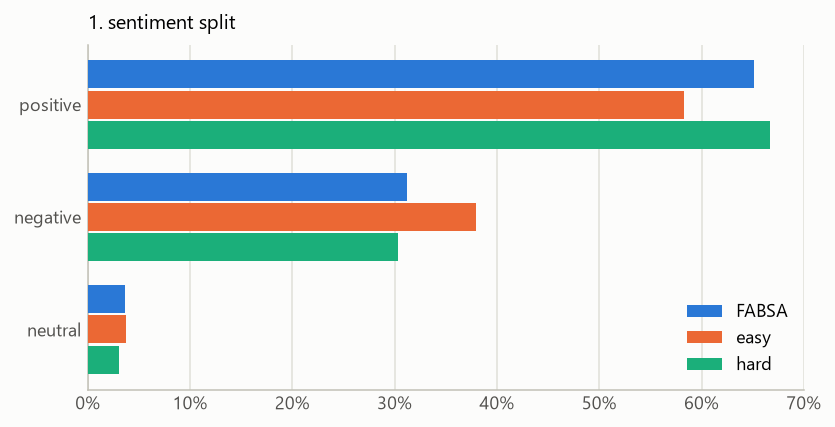

In [27]:
order = SENTIMENTS[::-1]
y     = np.arange(len(order))

fig, ax = plt.subplots(figsize=(6.6, 3.2))
for slot, (name, labels, colour) in enumerate(series):
    ax.barh(y + (1 - slot) * 0.27, shares(labels, "sentiment", order), 0.25,
            color=colour, label=name, zorder=3)
ax.set_yticks(y, order, fontsize=9)
ax.xaxis.set_major_formatter(PercentFormatter(1))
style(ax, axis="x", title="1. sentiment split").legend(frameon=False, fontsize=9, loc="lower right")
fig.savefig(FIG_DIR / f"p1_sentiment_{VERSION}.png", bbox_inches="tight")

split = pd.DataFrame({name: shares(labels, "sentiment", SENTIMENTS)
                      for name, labels, _ in series}) * 100
gaps  = {mode: (split[mode] - split.FABSA).abs().max() for mode in ("easy", "hard")}
print(split.round(1).to_string())
findings.append(f"1. sentiment split -- negative: FABSA {split.FABSA.negative:.1f}%, "
                f"hard {split.hard.negative:.1f}%, easy {split.easy.negative:.1f}% | "
                f"largest gap hard {gaps['hard']:.1f}pp, easy {gaps['easy']:.1f}pp. Easy runs "
                f"negative-heavy because its {MIN_REVIEWS}-review floor lifts the thin aspects, "
                "and the thin aspects are the negative-heavy ones (email, phone, account-access)")
print(f"\n{findings[-1]}")

### Plot 2: negative rate per industry

2. negative rate by industry (over the 7 industries FABSA covers) -- easy  rho 1.00  max gap 11.9pp
   hard  rho 1.00  max gap 7.2pp


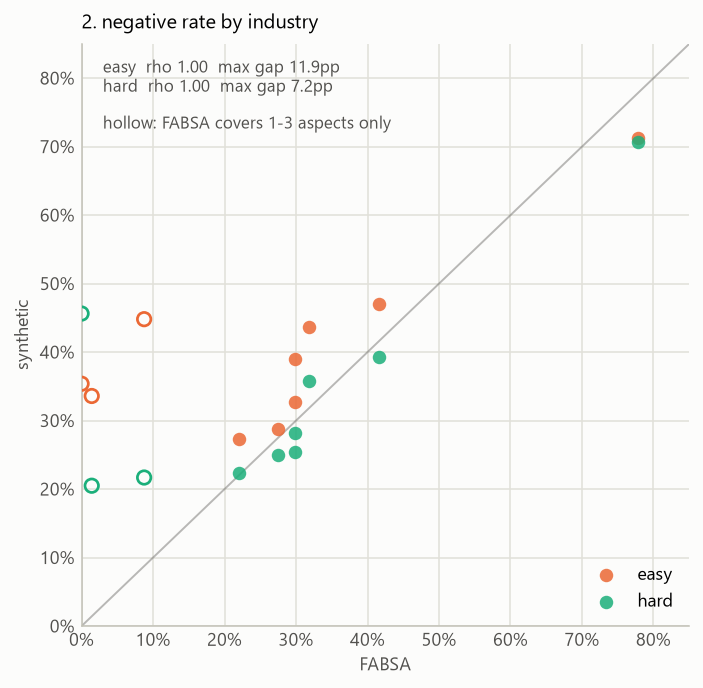

In [28]:
from scipy.stats import spearmanr

def neg_rate(labels):
    return labels.assign(neg=labels.sentiment.eq("negative")).groupby("industry").neg.mean()


# FABSA records 1-3 aspects for three industries and labels them almost entirely neutral, so they
# have no negative baseline to sit on. Drawn hollow and excluded from rho rather than dropped.
SPARSE  = [i for i in INDUSTRIES if FABSA[FABSA.industry == i].child_aspect.nunique() < len(ASPECTS)]
COVERED = [i for i in INDUSTRIES if i not in SPARSE]
base    = neg_rate(FABSA).reindex(INDUSTRIES)

fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.plot([0, 0.85], [0, 0.85], color=INK, lw=1, alpha=.4, zorder=2)
rhos = []
for name, labels, colour in series[1:]:
    got = neg_rate(labels).reindex(INDUSTRIES)
    ax.scatter(base[COVERED], got[COVERED], s=48, color=colour, lw=0, alpha=.85, zorder=4,
               label=name)
    ax.scatter(base[SPARSE], got[SPARSE], s=48, facecolors="none", edgecolors=colour, lw=1.4,
               zorder=4)
    rhos.append(f"{name}  rho {spearmanr(base[COVERED], got[COVERED]).statistic:.2f}  "
                f"max gap {(got[COVERED] - base[COVERED]).abs().max() * 100:.1f}pp")

ax.text(0.035, 0.975, "\n".join(rhos + ["", "hollow: FABSA covers 1-3 aspects only"]),
        transform=ax.transAxes, va="top", fontsize=8.5, color=INK)
ax.set(xlim=(0, 0.85), ylim=(0, 0.85))
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
style(ax, axis="both", title="2. negative rate by industry").legend(frameon=False, fontsize=9,
                                                                   loc="lower right")
ax.set_xlabel("FABSA", fontsize=9, color=INK)
ax.set_ylabel("synthetic", fontsize=9, color=INK)
fig.savefig(FIG_DIR / f"p2_negative_by_industry_{VERSION}.png", bbox_inches="tight")

findings.append(f"2. negative rate by industry (over the {len(COVERED)} industries FABSA covers) "
                f"-- {' | '.join(rhos)}")
print(findings[-1].replace(" | ", "\n   "))

### Plot 3: presence heatmap

FABSA     91/120 present
easy     120/120 present
hard      91/120 present

3. presence -- hard reproduces FABSA's holes exactly: True (29 absent groups); easy fills all 120


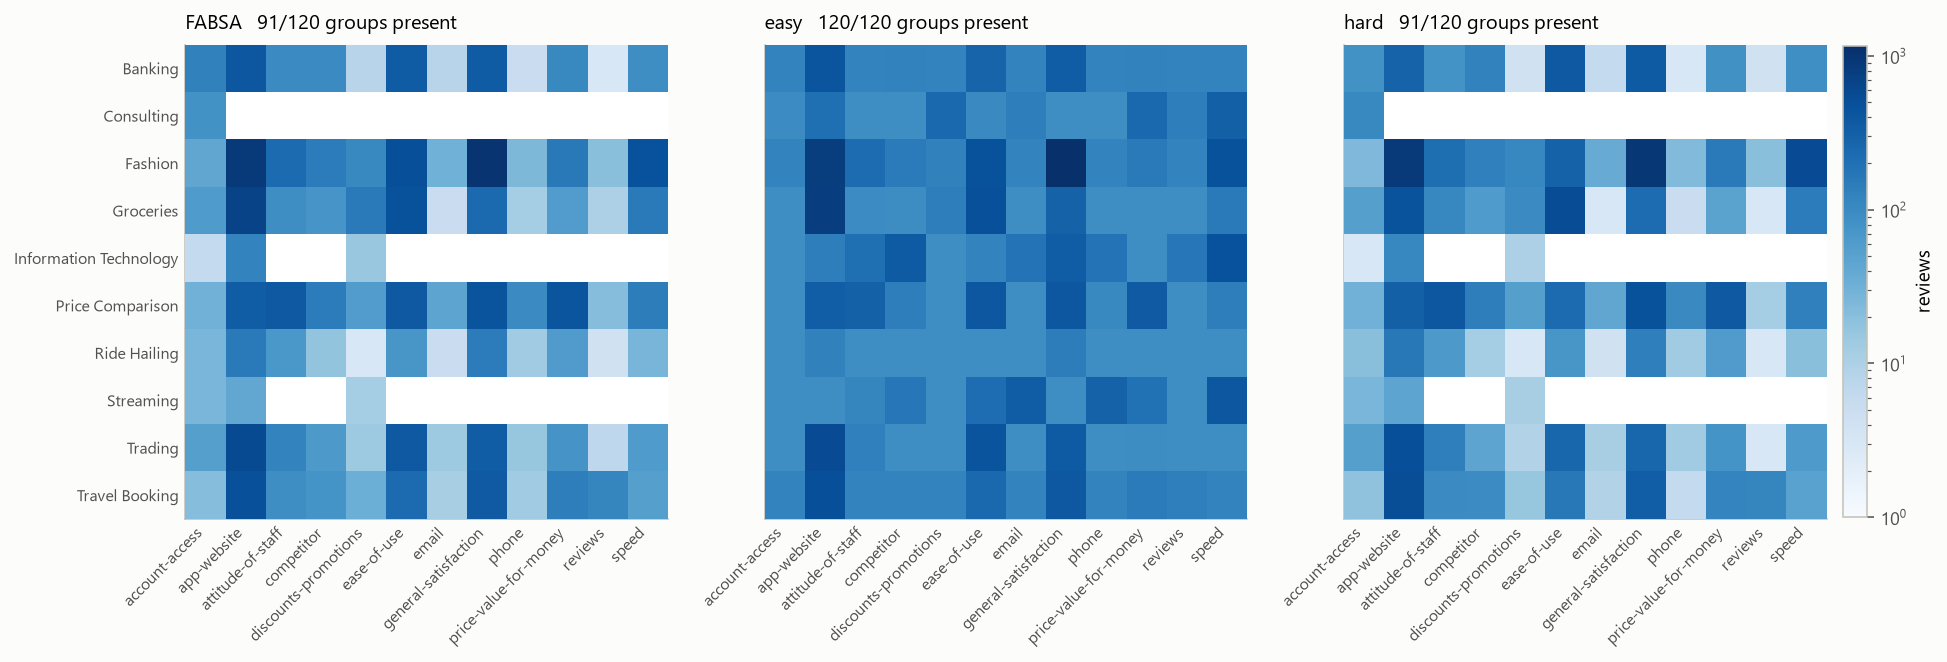

In [29]:
from matplotlib.colors import LogNorm

# Plot 3 -- which industry x aspect groups exist at all. White is absent. FABSA and Hard should
# carry the same holes; Easy should have none.
FRAME = pd.MultiIndex.from_product([INDUSTRIES, ASPECTS])


def group_grid(labels):
    """The 10 x 12 frame of review counts, NaN where the group was never recorded."""
    return (labels.groupby(["industry", "child_aspect"]).size()
            .reindex(FRAME).unstack().reindex(index=INDUSTRIES, columns=ASPECTS))


grids = [(name, group_grid(labels)) for name, labels, _ in series]
cmap  = plt.get_cmap("Blues").copy(); cmap.set_bad("#ffffff")
vmax  = max(g.max().max() for _, g in grids)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
for ax, (name, g) in zip(axes, grids):
    im = ax.imshow(g.values, cmap=cmap, norm=LogNorm(vmin=1, vmax=vmax), aspect="auto", zorder=3)
    ax.set_xticks(range(len(ASPECTS)), ASPECTS, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(INDUSTRIES)), INDUSTRIES if ax is axes[0] else [], fontsize=8)
    ax.set_xticks(np.arange(-.5, len(ASPECTS)), minor=True)
    ax.set_yticks(np.arange(-.5, len(INDUSTRIES)), minor=True)
    ax.grid(which="minor", color=GRID, lw=0.8, zorder=4)
    ax.tick_params(length=0, which="both")
    present = int(g.notna().sum().sum())
    ax.set_title(f"{name}   {present}/{g.size} groups present", loc="left", fontsize=10.5, pad=8)
fig.colorbar(im, ax=axes, fraction=0.014, pad=0.01, label="reviews")
fig.savefig(FIG_DIR / f"p3_presence_{VERSION}.png", bbox_inches="tight")

holes = {name: set(g.stack(future_stack=True).index[g.stack(future_stack=True).isna()])
         for name, g in grids}
print(pd.Series({name: f"{int(g.notna().sum().sum())}/{g.size} present" for name, g in grids})
      .to_string())
findings.append(f"3. presence -- hard reproduces FABSA's holes exactly: "
                f"{holes['hard'] == holes['FABSA']} ({len(holes['FABSA'])} absent groups); "
                f"easy fills all {grids[1][1].size}")
print(f"\n{findings[-1]}")

### Plot 4: cell size distribution

FABSA (group / orgs)    60.4% under 30 | median 23
easy                     0.0% under 30 | median 30
hard                    58.9% under 30 | median 24

4. cell size -- under 30 reviews: FABSA 60.4%, hard 58.9%, easy 0.0% (floored by construction)

wrote ..\benchmark_outputs\v2\validation_report.txt


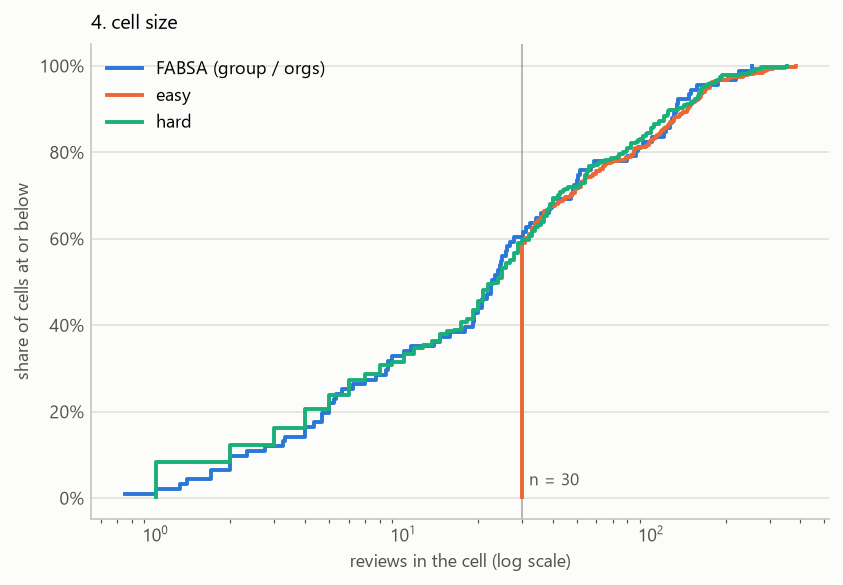

In [30]:
# Plot 4 -- how big the surviving cells are. FABSA is shown per org (its group size divided by the
# industry's org count), which is the quantity step 6 samples, so the three curves are comparable.
def ecdf(values):
    v = np.sort(np.asarray(values, dtype=float))
    return v, np.arange(1, len(v) + 1) / len(v)


fabsa_groups = FABSA.groupby(["industry", "child_aspect"]).size()
fabsa_cells  = fabsa_groups / [len(ORGS[i]) for i, _ in fabsa_groups.index]
curves = [("FABSA (group / orgs)", fabsa_cells, REAL),
          ("easy", DATASETS["easy"][1].n_reviews, EASY),
          ("hard", DATASETS["hard"][1].n_reviews, HARD)]

fig, ax = plt.subplots(figsize=(6.8, 4.4))
ax.axvline(MIN_REVIEWS, color=INK, lw=1, alpha=.4, zorder=2)
ax.text(MIN_REVIEWS * 1.07, 0.03, f"n = {MIN_REVIEWS}", fontsize=8.5, color=INK)
for name, values, colour in curves:
    x, y = ecdf(values)
    ax.step(x, y, where="post", color=colour, lw=2, label=name, zorder=3)
ax.set_xscale("log")
ax.yaxis.set_major_formatter(PercentFormatter(1))
style(ax, title="4. cell size").legend(frameon=False, fontsize=9, loc="upper left")
ax.set_xlabel("reviews in the cell (log scale)", fontsize=9, color=INK)
ax.set_ylabel("share of cells at or below", fontsize=9, color=INK)
fig.savefig(FIG_DIR / f"p4_cell_size_{VERSION}.png", bbox_inches="tight")

thin = {name: float((np.asarray(v, dtype=float) < MIN_REVIEWS).mean()) for name, v, _ in curves}
print(pd.Series({n: f"{thin[n]:.1%} under {MIN_REVIEWS} | median {np.median(v):.0f}"
                 for n, v, _ in curves}).to_string())
findings.append(f"4. cell size -- under {MIN_REVIEWS} reviews: "
                f"FABSA {thin['FABSA (group / orgs)']:.1%}, hard {thin['hard']:.1%}, "
                f"easy {thin['easy']:.1%} (floored by construction)")
print(f"\n{findings[-1]}")

# ---- the guards behind the four figures ---------------------------------------------------
# Hard is held tight to FABSA; Easy is allowed a wider sentiment band because its review floor
# necessarily lifts the thin, negative-heavy aspects. Both are bounded so a regression still trips.
easy_cells, hard_cells = DATASETS["easy"][1], DATASETS["hard"][1]
retained = len(hard_cells) / len(easy_cells)
assert holes["hard"] == holes["FABSA"], "hard's missing groups no longer match FABSA's"
assert not holes["easy"], "easy is meant to fill the whole frame"
assert gaps["hard"] < 2, f"hard moved the sentiment split by {gaps['hard']:.1f}pp"
assert gaps["easy"] < 8, f"easy's floor drift grew to {gaps['easy']:.1f}pp"
assert abs(thin["hard"] - thin["FABSA (group / orgs)"]) < 0.10, "hard no longer tracks FABSA's sizes"
assert 0.60 <= retained <= 0.75, f"retention {retained:.1%} outside the 60-75% target"
assert thin["hard"] > 0.05, "hard has almost no thin cells -- it is not meaningfully sparser"
for mode, (_, cells) in DATASETS.items():
    pairs = cells[cells.is_planted_null].groupby(["industry", "child_aspect"]).agg(
        orgs=("org", "nunique"), rates=("planted_neg_rate", "nunique"))
    assert pairs.orgs.eq(2).all() and pairs.rates.eq(1).all(), f"{mode}: a planted null broke"

findings.insert(0, f"dataset generation {VERSION} | seed {SEED} | drop_rate {DROP_RATE}\n")
findings.append(f"\ncells retained {len(hard_cells)}/{len(easy_cells)} = {retained:.1%} "
                f"(target 60-75%) | reviews {len(DATASETS['hard'][0]):,} hard vs "
                f"{len(DATASETS['easy'][0]):,} easy vs {len(FABSA):,} FABSA")
(OUT_DIR / "validation_report.txt").write_text("\n".join(findings) + "\n")
print(f"\nwrote {OUT_DIR / 'validation_report.txt'}")

## Step 10 - Freeze

**Do:** fixed seed, versioned outputs, one config file carrying every parameter.

**Why:** one script and one flag produce both modes, so "same process, different sparsity" is
checkable rather than asserted.

In [31]:
import yaml

CONFIG = {
    "version": VERSION, "seed": SEED, "source": "clean_fabsa.csv",
    "min_reviews": MIN_REVIEWS, "drop_rate": DROP_RATE,
    "size_jitter": list(SIZE_JITTER), "neg_limits": list(NEG_LIMITS),
    "offsets": OFFSET_CHOICES + [MAX_OFFSET], "min_margin": MIN_MARGIN,
    "industries": INDUSTRIES, "aspects": ASPECTS, "parent_of": PARENT_OF, "orgs": ORGS,
    "tied_aspect": TIED_ASPECT, "null_pair": {i: list(p) for i, p in NULL_PAIR.items()},
    "cells": {mode: len(cells) for mode, (_, cells) in DATASETS.items()},
    "reviews": {mode: len(labels) for mode, (labels, _) in DATASETS.items()},
    "outputs": {"agent_sees": "{mode}/labels.csv", "scorer_sees": "{mode}/cells.csv",
                "ground_truth": "offsets.csv", "validation": "validation_report.txt"},
}
(OUT_DIR / "generation_config.yaml").write_text(yaml.safe_dump(CONFIG, sort_keys=False))
print(f"froze {VERSION}: {sorted(p.name for p in OUT_DIR.iterdir())}")

froze v2: ['easy', 'generation_config.yaml', 'hard', 'offsets.csv', 'validation_report.txt']


## Aspect and sentiment distributions: FABSA vs Easy vs Hard

One run produces both datasets, so they can be read side by side against the source.

- **Aspect prevalence** shows what sparsity costs. Easy tracks FABSA loosely because its 30-review
  floor inflates every thin aspect; Hard tracks it closely because it inherits FABSA's volumes.
- **Sentiment split** should be close in both. The negative share runs a little above FABSA in each,
  which is the planted offsets showing up: they are net positive by design, since every org gets one
  large positive offset for its biggest problem.

child_aspect (% of reviews, and the gap in percentage points)
                       FABSA  easy  hard  easy - FABSA  hard - FABSA
child_aspect                                                        
account-access           3.4   4.3   3.3           0.9          -0.1
app-website             26.1  16.9  25.6          -9.2          -0.5
attitude-of-staff        7.7   6.4   8.6          -1.3           0.9
competitor               4.4   6.1   4.7           1.7           0.3
discounts-promotions     2.9   5.2   2.5           2.3          -0.4
ease-of-use             16.9  12.2  15.2          -4.7          -1.7
email                    0.9   5.9   0.9           5.1           0.0
general-satisfaction    20.8  15.6  21.3          -5.2           0.6
phone                    1.3   5.6   1.3           4.3          -0.0
price-value-for-money    7.3   6.9   7.2          -0.4          -0.1
reviews                  1.3   4.8   1.3           3.6          -0.0
speed                    7.2  10.1   8.2 

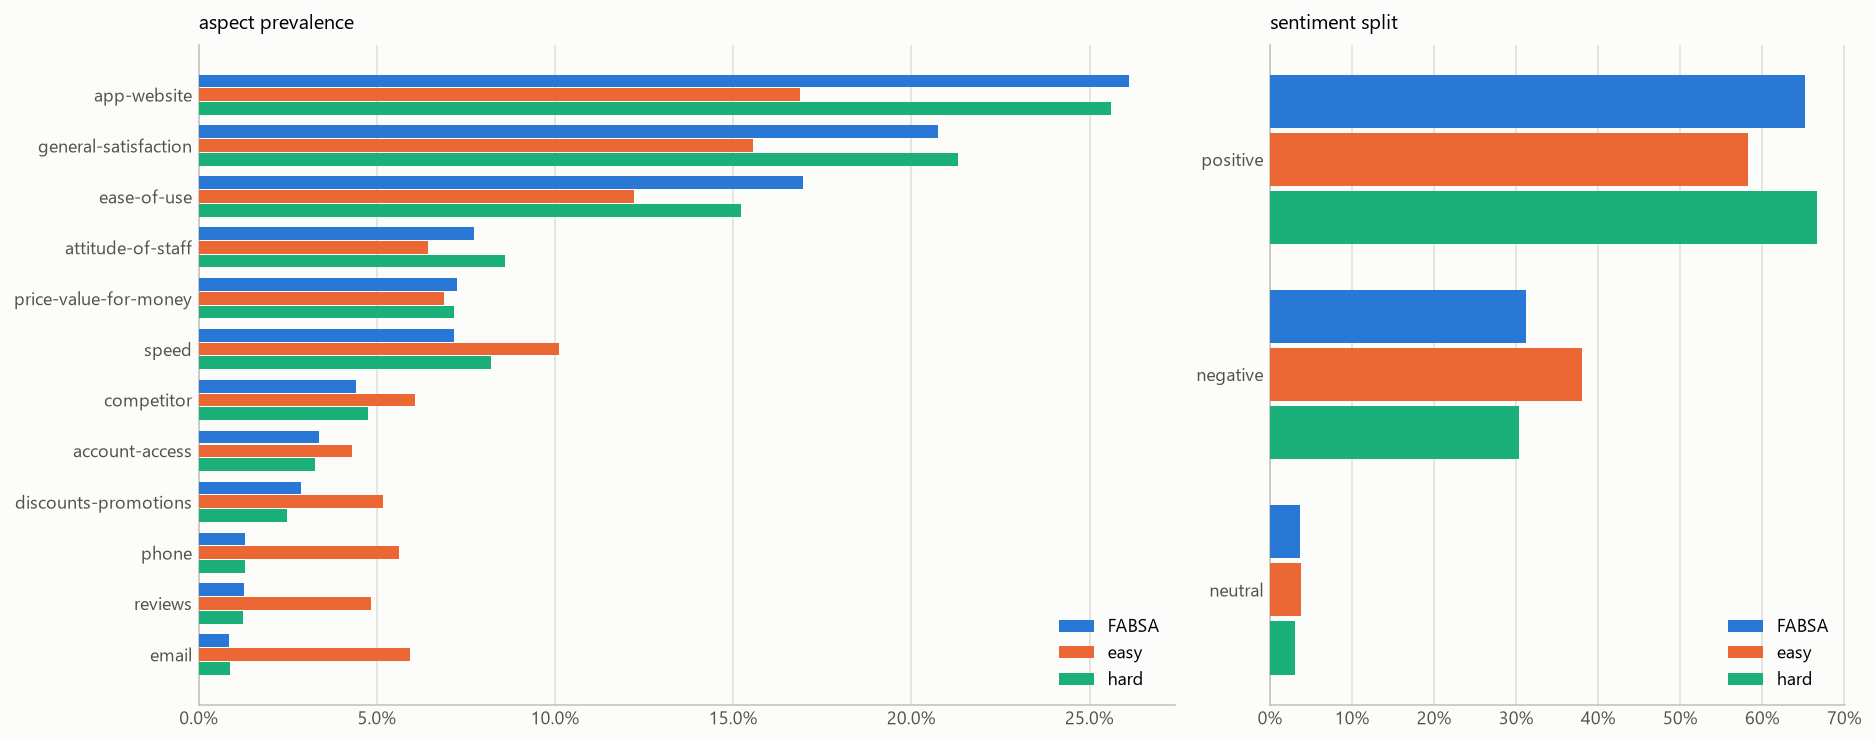

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), gridspec_kw={"width_ratios": [1.7, 1]})
for ax, (column, order, title) in zip(axes, [("child_aspect", aspect_order, "aspect prevalence"),
                                             ("sentiment", SENTIMENTS[::-1], "sentiment split")]):
    y = np.arange(len(order))
    for slot, (name, labels, colour) in enumerate(series):
        ax.barh(y + (1 - slot) * 0.27, shares(labels, column, order), 0.25,
                color=colour, label=name, zorder=3)
    ax.set_yticks(y, order, fontsize=9)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    style(ax, axis="x", title=title).legend(frameon=False, fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / f"distributions_{VERSION}.png", bbox_inches="tight")

for column, order in [("child_aspect", ASPECTS), ("sentiment", SENTIMENTS)]:
    table = pd.DataFrame({name: shares(labels, column, order) for name, labels, _ in series}) * 100
    table["easy - FABSA"] = (table.easy - table.FABSA).round(1)
    table["hard - FABSA"] = (table.hard - table.FABSA).round(1)
    print(f"{column} (% of reviews, and the gap in percentage points)")
    print(table.round(1).to_string(), end="\n\n")

## Per-industry breakdown

The same comparison split by industry. The aggregate above can hide a mode that tracks FABSA
overall while distorting individual industries, which is where the questions are actually asked.

- **Aspect prevalence** is a share of that industry's own reviews, so each panel sums to 100%.
  Panels carry their own x-scale: the industries FABSA barely covers sit on one or two aspects and
  would flatten a shared axis. Hard should hug FABSA; Easy should spread wider, because its
  30-review floor invents the aspects FABSA never recorded.
- **Sentiment split** shares one x-scale across all three panels, since all three sentiments are
  shares of the same denominator. Both modes should sit close to FABSA, with negative running
  slightly high - the planted offsets are net positive by design.

**Read both with Consulting, Information Technology and Streaming set aside.** FABSA records 1-3
aspects for them and labels 91-100% of those reviews neutral, so there is no aspect mix and no
positive/negative baseline there to be faithful to. Hard inherits the degeneracy; Easy imputes
past it from the aspect averages. Their gaps dominate any average that includes them, so the
summaries below report the seven covered industries separately from these three.

aspect-mix distance from FABSA, per industry (0 = identical, 1 = no overlap)
                        fabsa_aspects   easy   hard
Banking                            12  0.212  0.095
Consulting                          1  0.948  0.000
Fashion                            12  0.099  0.059
Groceries                          12  0.109  0.108
Information Technology              3  0.870  0.042
Price Comparison                   12  0.088  0.060
Ride Hailing                       12  0.379  0.040
Streaming                           3  0.875  0.029
Trading                            12  0.153  0.066
Travel Booking                     12  0.192  0.069

7 industries FABSA covers fully: easy 0.176 | hard 0.071
Consulting, Information Technology, Streaming (1-3 aspects recorded): easy 0.898 | hard 0.024
the second line is Easy's 30-review floor inventing aspects FABSA never recorded -- by design, but it is why aggregate fidelity should be read off the first


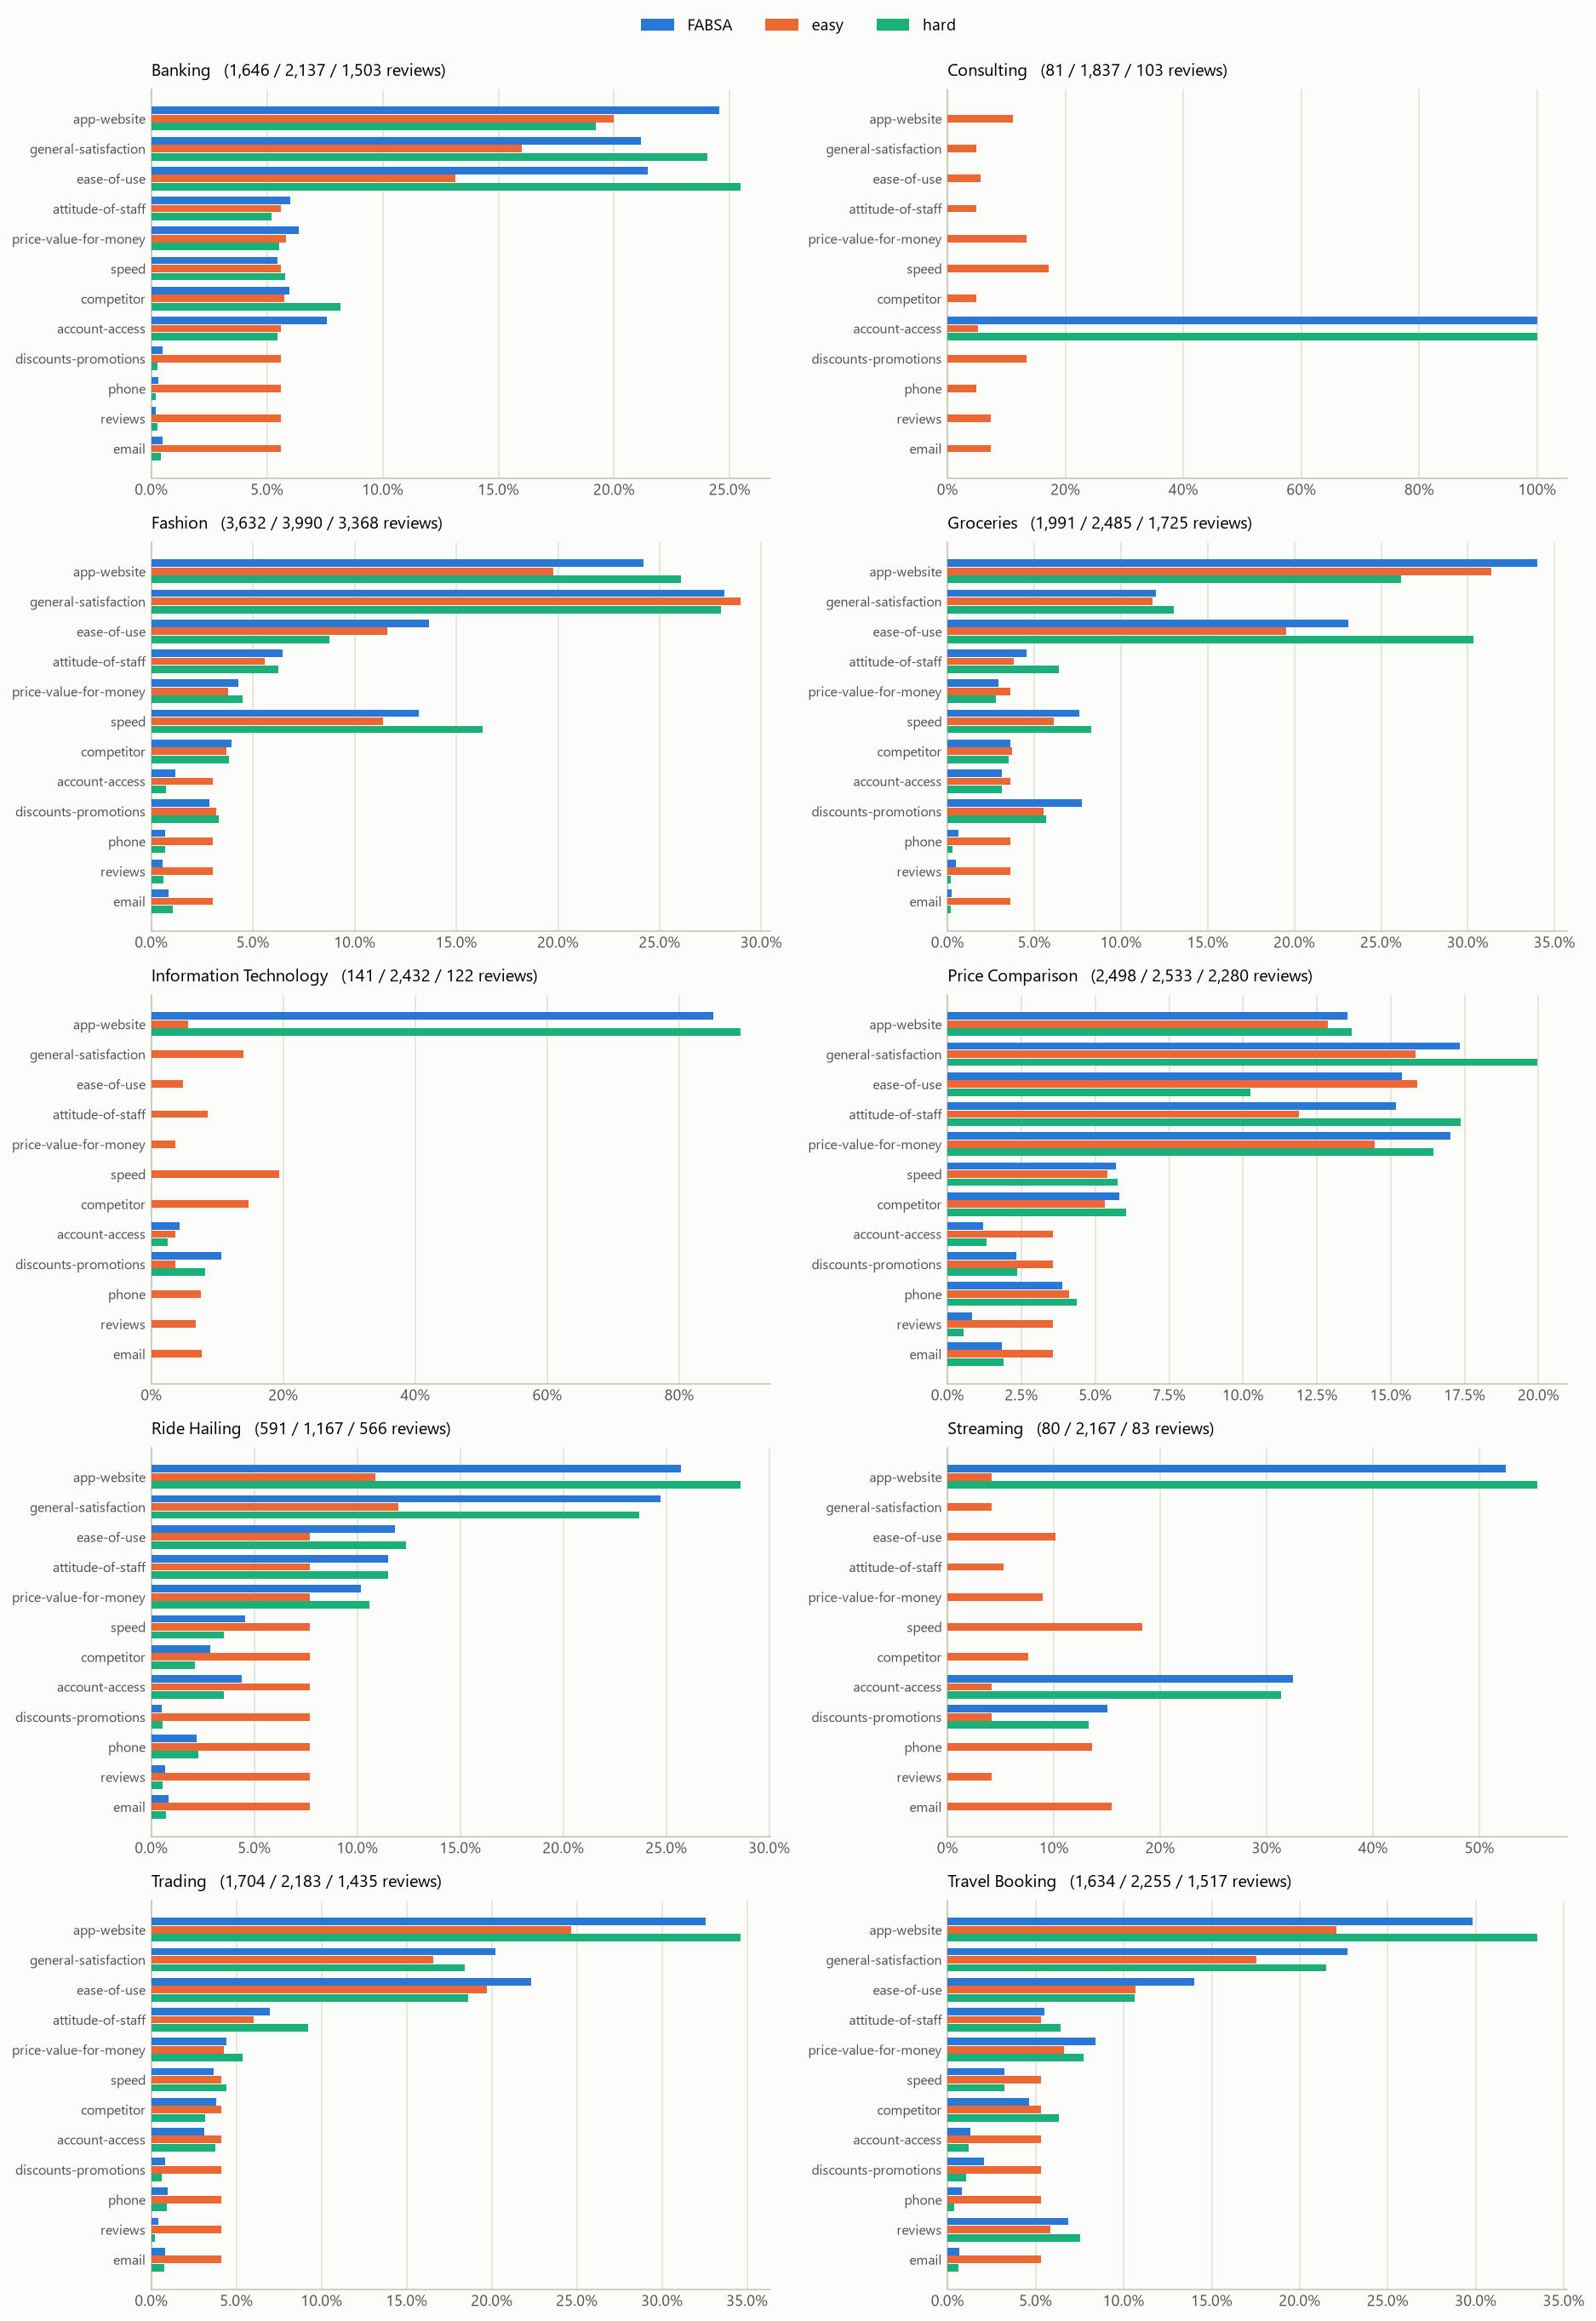

In [33]:
def industry_shares(labels, industry, column, order):
    """How this industry's reviews divide across `order` -- zero where the value never appears."""
    rows = labels[labels.industry == industry]
    return rows[column].value_counts(normalize=True).reindex(order).fillna(0)


fig, axes = plt.subplots(5, 2, figsize=(13.5, 19.5))
for ax, industry in zip(axes.ravel(), INDUSTRIES):
    y = np.arange(len(aspect_order))
    for slot, (name, labels, colour) in enumerate(series):
        ax.barh(y + (1 - slot) * 0.27,
                industry_shares(labels, industry, "child_aspect", aspect_order),
                0.25, color=colour, label=name, zorder=3)
    ax.set_yticks(y, aspect_order, fontsize=8)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    sizes = " / ".join(f"{(labels.industry == industry).sum():,}" for _, labels, _ in series)
    style(ax, axis="x", title=f"{industry}   ({sizes} reviews)")

fig.tight_layout(rect=(0, 0, 1, 0.982))
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3,
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.0))
fig.savefig(FIG_DIR / f"aspects_by_industry_{VERSION}.png", bbox_inches="tight")

# How far each mode's aspect mix sits from FABSA's, per industry: total variation distance --
# the share of reviews that would have to move to another aspect to match FABSA exactly.
drift = pd.DataFrame(
    {mode: [(industry_shares(labels, i, "child_aspect", ASPECTS)
             - industry_shares(FABSA, i, "child_aspect", ASPECTS)).abs().sum() / 2
            for i in INDUSTRIES] for mode, (labels, _) in DATASETS.items()},
    index=INDUSTRIES)
drift.insert(0, "fabsa_aspects", FABSA.groupby("industry").child_aspect.nunique())

# Three industries sit on 1-3 aspects in FABSA, so there is barely a mix there to match. They are
# reported apart, or they carry an average that says nothing about the seven that are covered.
SPARSE  = [i for i in INDUSTRIES if drift.fabsa_aspects[i] < len(ASPECTS)]
covered = drift.drop(index=SPARSE)
print("aspect-mix distance from FABSA, per industry (0 = identical, 1 = no overlap)")
print(drift.round(3).to_string())
print(f"\n{len(covered)} industries FABSA covers fully: "
      f"easy {covered.easy.mean():.3f} | hard {covered.hard.mean():.3f}")
print(f"{', '.join(SPARSE)} ({drift.fabsa_aspects[SPARSE].min()}-"
      f"{drift.fabsa_aspects[SPARSE].max()} aspects recorded): "
      f"easy {drift.loc[SPARSE].easy.mean():.3f} | hard {drift.loc[SPARSE].hard.mean():.3f}")
print("the second line is Easy's 30-review floor inventing aspects FABSA never recorded -- "
      "by design, but it is why aggregate fidelity should be read off the first")

sentiment split by industry (% of that industry's reviews)
                          FABSA                      easy                      hard                 
sentiment              positive negative neutral positive negative neutral positive negative neutral
Banking                    61.8     29.8     8.4     53.5     38.9     7.5     63.9     28.1     7.9
Consulting                  0.0      0.0   100.0     59.7     35.4     4.9      3.9     45.6    50.5
Fashion                    72.3     27.5     0.2     69.9     28.8     1.2     74.4     25.0     0.6
Groceries                  57.4     41.6     1.1     50.1     47.0     2.9     58.7     39.3     2.0
Information Technology      0.0      1.4    98.6     58.5     33.6     7.9     26.2     20.5    53.3
Price Comparison           77.5     22.1     0.5     72.1     27.3     0.6     77.2     22.3     0.4
Ride Hailing               19.5     77.8     2.7     22.4     71.2     6.4     25.4     70.7     3.9
Streaming                   0.0 

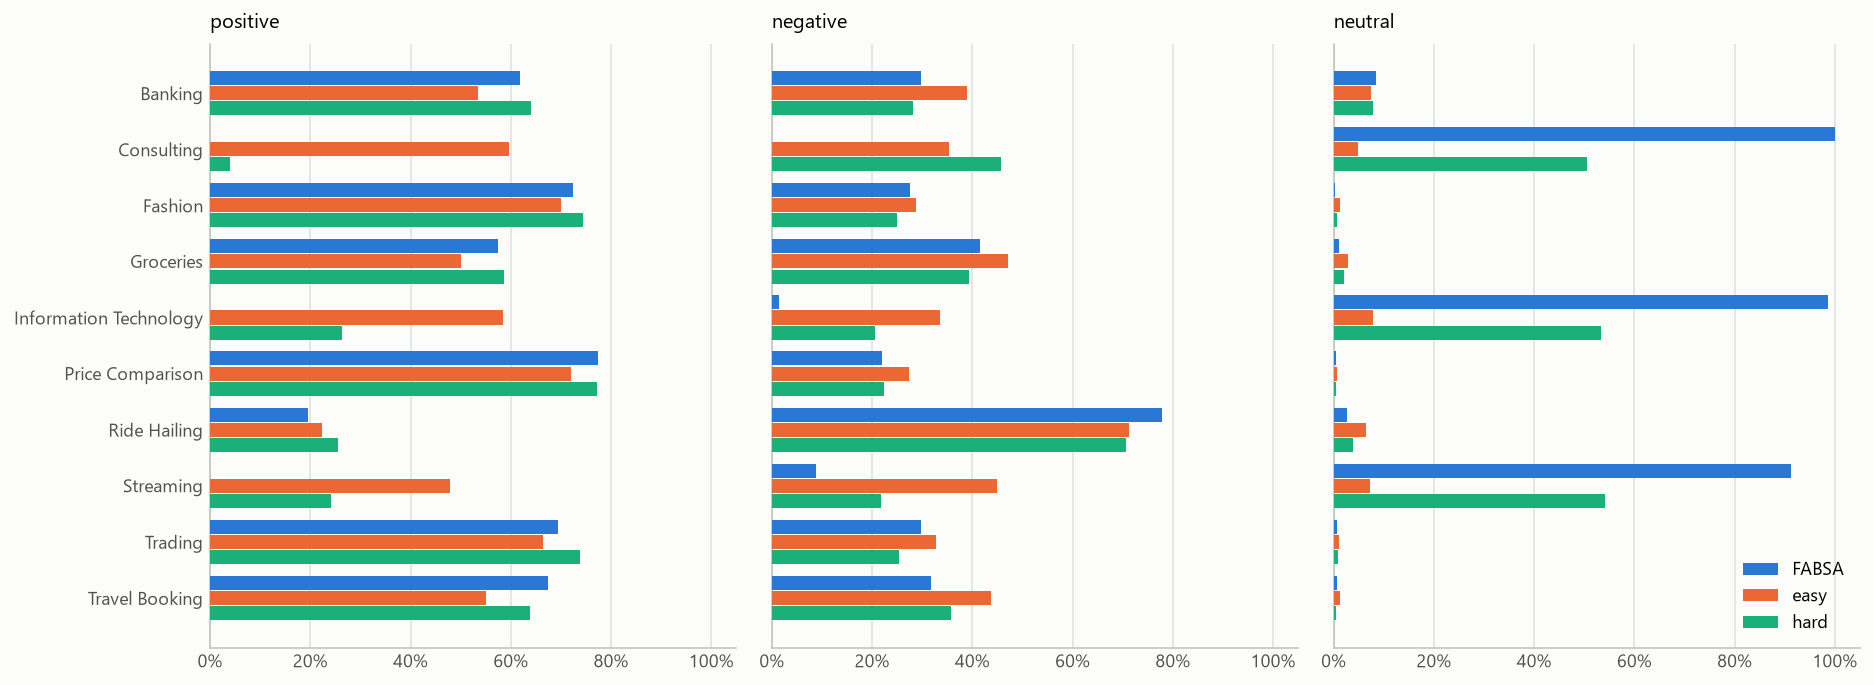

In [34]:
order = INDUSTRIES[::-1]                      # barh fills upward; reversed reads alphabetically
y     = np.arange(len(order))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.0), sharex=True)
for ax, sentiment in zip(axes, SENTIMENTS):
    for slot, (name, labels, colour) in enumerate(series):
        ax.barh(y + (1 - slot) * 0.27,
                [industry_shares(labels, i, "sentiment", SENTIMENTS)[sentiment] for i in order],
                0.25, color=colour, label=name, zorder=3)
    ax.set_yticks(y, order if ax is axes[0] else [], fontsize=9)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    style(ax, axis="x", title=sentiment)
axes[-1].legend(frameon=False, fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / f"sentiment_by_industry_{VERSION}.png", bbox_inches="tight")

split = pd.concat({name: pd.DataFrame(
    [industry_shares(labels, i, "sentiment", SENTIMENTS) for i in INDUSTRIES], index=INDUSTRIES)
    for name, labels, _ in series}, axis=1) * 100
print("sentiment split by industry (% of that industry's reviews)")
print(split.round(1).to_string())

# The same three industries again: FABSA labels them almost entirely neutral, so there is no
# positive/negative baseline to match and their gap says nothing about how faithful a mode is.
for mode in ("easy", "hard"):
    gaps = (split[mode].negative - split.FABSA.negative).abs().drop(SPARSE)
    print(f"\n{mode:5s} negative-share gap vs FABSA over the {len(gaps)} covered industries: "
          f"max {gaps.max():.1f}pp ({gaps.idxmax()}), mean {gaps.mean():.1f}pp")
print(f"\nexcluded: {', '.join(SPARSE)} -- FABSA labels them "
      f"{split.FABSA.neutral[SPARSE].min():.0f}-{split.FABSA.neutral[SPARSE].max():.0f}% neutral. "
      "Hard inherits that, Easy imputes past it")